In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
%cd /content/drive/MyDrive/Galaxy_Hackers/

/content/drive/MyDrive/Galaxy_Hackers


In [ ]:
!ls

 ACT_90_DR6.fits		  planck217_fully_masked.fits
 bbdm_cmb.zip			  Planck_217_R3.fits
 Diffusion			  planck217_reprojected.fits
'Diffusion model.ipynb'		  Planck+ACT_150_DR4DR6.fits
 noisy_animation_planck+act.gif   planck+act150_final_uK.fits
 planck100_fully_masked.fits	  Planck+ACT_220_DR6.fits
 Planck_100_R3.fits		  planck+act220_final_uK.fits
 planck100_reprojected.fits	  Planck+ACT_90_DR4DR6.fits
 planck143_fully_masked.fits	  planck+act90_final_uK.fits
 Planck_143_R3.fits		  Planck_Masks.fits
 planck143_reprojected.fits	  Planck_tiles


In [ ]:
!pip -q install healpy pixell reproject astropy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.0/191.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.8/379.8 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.8/190.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 101.9 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from tqdm import tqdm
from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import mad_std, sigma_clip
from reproject import reproject_from_healpix
from pixell import enmap


In [ ]:
FILES = {
    100: "Planck_100_R3.fits",
    143: "Planck_143_R3.fits",
    217: "Planck_217_R3.fits",
}

gal_mask_path  = "Planck_Masks.fits"

tile_deg_size  = 8.0
patch_dir = "patches_inference"
patch_size = 480
patch_stride = patch_size // 2
nside_out = 8192
pixel_size_deg = 0.5 / 60

In [ ]:
with fits.open(gal_mask_path) as hdul:
    gal_mask = np.asarray(hdul[1].data["GAL-MASK"], dtype=np.float32)
print(f"  Покрытие: {(gal_mask > 0.5).mean()*100:.1f}%")
print(f"  NSIDE: {hp.get_nside(gal_mask)}")

planck_maps = {}
for freq, path in tqdm(FILES.items(), desc="Загрузка карт"):
    m = hp.read_map(path, nest=True)
    m = hp.ud_grade(m, nside_out=nside_out, order_in="NESTED", order_out="RING")
    planck_maps[freq] = m
    tqdm.write(f"  {freq} ггц — NSIDE: {hp.get_nside(m)} | пикселей: {len(m):,}")


  Покрытие: 60.0%
  NSIDE: 2048


Загрузка карт:  33%|███▎      | 1/3 [01:45<03:30, 105.45s/it]

  100 ггц — NSIDE: 8192 | пикселей: 805,306,368


Загрузка карт:  67%|██████▋   | 2/3 [02:54<01:23, 83.80s/it] 

  143 ггц — NSIDE: 8192 | пикселей: 805,306,368


Загрузка карт: 100%|██████████| 3/3 [03:59<00:00, 79.76s/it]

  217 ггц — NSIDE: 8192 | пикселей: 805,306,368


In [ ]:
def make_tan_wcs(ra_center, dec_center, pixel_size_deg, tile_size_px):
    w = WCS(naxis=2)
    w.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    w.wcs.crval = [ra_center, dec_center]
    w.wcs.crpix = [tile_size_px / 2 + 0.5, tile_size_px / 2 + 0.5]
    w.wcs.cdelt = [-pixel_size_deg, pixel_size_deg]
    return w


def reproject_tile(healpix_map, wcs, tile_size_px):
    data, _ = reproject_from_healpix(
        (healpix_map, "galactic"),
        wcs,
        shape_out=(tile_size_px, tile_size_px),
        order="bilinear",
        nested=False,
    )
    return data.astype(np.float32)


def reproject_mask_tile(healpix_mask, wcs, tile_size_px):
    data, _ = reproject_from_healpix(
        (healpix_mask, "galactic"),
        wcs,
        shape_out=(tile_size_px, tile_size_px),
        order="nearest-neighbor",
        nested=False,
    )
    return data > 0.5


def sigma_clip_tile(tile, mask_valid):
    valid_vals = tile[mask_valid]
    if valid_vals.size == 0:
        return tile

    clipped = sigma_clip(valid_vals, sigma=3.0, maxiters=5,
                         cenfunc="median", stdfunc="mad_std")
    vals_kept = clipped.data[~clipped.mask]
    if vals_kept.size == 0:
        return tile

    low  = np.median(vals_kept) - 3.0 * mad_std(vals_kept)
    high = np.median(vals_kept) + 3.0 * mad_std(vals_kept)

    out = tile.copy()
    out[mask_valid] = np.clip(valid_vals, low, high)
    out[~mask_valid] = 0.0
    return out


def extract_patches(tile, patch_size, stride):
    h, w = tile.shape
    patches = []
    y = 0
    while True:
        if y + patch_size > h:
            y = h - patch_size
        x = 0
        while True:
            if x + patch_size > w:
                x = w - patch_size
            patch = tile[y:y+patch_size, x:x+patch_size]
            if np.any(patch):
                patches.append(patch)
            if x + patch_size >= w:
                break
            x += stride
        if y + patch_size >= h:
            break
        y += stride
    return patches



In [ ]:
tile_size_px = int(tile_deg_size / pixel_size_deg)
step_deg     = tile_deg_size * 0.5

dec_steps   = np.arange(tile_deg_size / 2, 90 - tile_deg_size / 2, step_deg)
dec_centers = np.concatenate((-dec_steps[::-1], [0.0], dec_steps))
ra_centers  = np.arange(0.0, 360.0, step_deg)

print(f"Tile size:    {tile_size_px}px ({tile_deg_size}°)")
print(f"Dec centers:  {len(dec_centers)} ({dec_centers[0]:.1f}° → {dec_centers[-1]:.1f}°)")
print(f"RA centers:   {len(ra_centers)}")
print(f"Total tiles:  {len(dec_centers) * len(ra_centers):,}")

Tile size:    960px (8.0°)
Dec centers:  43 (-84.0° → 84.0°)
RA centers:   90
Total tiles:  3,870


In [ ]:
def is_tile_masked(ra, dec, healpix_mask, half=tile_deg_size/2):
    probe_points = [
        (ra - half, dec - half), (ra - half, dec + half),
        (ra + half, dec - half), (ra + half, dec + half),
        (ra, dec - half),        (ra, dec + half),
        (ra - half, dec),        (ra + half, dec),
    ]
    phi   = np.deg2rad(np.mod([p[0] for p in probe_points], 360.0))
    theta = np.deg2rad(90.0 - np.array([p[1] for p in probe_points]))
    nside = hp.get_nside(healpix_mask)
    pix   = hp.ang2pix(nside, theta, phi, nest=False)
    return not healpix_mask[pix].any()

In [ ]:
gal_mask_bool = gal_mask > 0.5
tile_masks = {}
skipped_probe = 0
skipped_empty = 0

for dec in tqdm(dec_centers, desc="Dec rows"):
    for ra in ra_centers:
        if is_tile_masked(ra, dec, gal_mask_bool):
            skipped_probe += 1
            continue

        wcs = make_tan_wcs(ra, dec, pixel_size_deg, tile_size_px)
        mask_tile = reproject_mask_tile(gal_mask, wcs, tile_size_px)

        if mask_tile.any():
            tile_masks[(ra, dec)] = mask_tile
        else:
            skipped_empty += 1

print(f"\nВалидных тайлов:             {len(tile_masks):,}")
print(f"Скипнуто по пробе:   {skipped_probe:,}")
print(f"Скип после репроекции: {skipped_empty:,}")
print(f"Память маски: {sum(m.nbytes for m in tile_masks.values()) / 1024**2:.1f} MB")

Dec rows: 100%|██████████| 43/43 [27:46<00:00, 38.76s/it]


Валидных тайлов:             2,186
Скипнуто по пробе:   735
Скип после репроекции: 949
Память маски: 1921.3 MB


#####100 ghz

In [ ]:
os.makedirs(os.path.join(patch_dir, "f100"), exist_ok=True)
freq_dir = os.path.join(patch_dir, "f100")

for (ra, dec), mask_tile in tqdm(tile_masks.items(), desc="f100 tiles", total=len(tile_masks)):
    wcs = make_tan_wcs(ra, dec, pixel_size_deg, tile_size_px)
    tile = reproject_tile(planck_maps[100], wcs, tile_size_px)
    tile_masked = sigma_clip_tile(tile, mask_tile)
    fpath = os.path.join(freq_dir, f"tile_ra{ra:+g}_dec{dec:+g}.fits")
    hdu = fits.PrimaryHDU(tile_masked)
    hdu.header["FREQ"]  = 100
    hdu.header["RA"]    = ra
    hdu.header["DEC"]   = dec
    hdu.header["BUNIT"] = "uK"
    hdu.writeto(fpath, overwrite=True)

print(f"Saved {len(os.listdir(freq_dir)):,} tiles → {freq_dir}")

f100 tiles: 100%|██████████| 2186/2186 [1:11:33<00:00,  1.96s/it]

Saved 2,186 tiles → patches_inference/f100


#####143 ghz

In [ ]:
os.makedirs(os.path.join(patch_dir, "f143"), exist_ok=True)
freq_dir = os.path.join(patch_dir, "f143")

for (ra, dec), mask_tile in tqdm(tile_masks.items(), desc="f143 tiles", total=len(tile_masks)):
    wcs = make_tan_wcs(ra, dec, pixel_size_deg, tile_size_px)
    tile = reproject_tile(planck_maps[143], wcs, tile_size_px)
    tile_masked = sigma_clip_tile(tile, mask_tile)
    fpath = os.path.join(freq_dir, f"tile_ra{ra:+g}_dec{dec:+g}.fits")
    hdu = fits.PrimaryHDU(tile_masked)
    hdu.header["FREQ"]  = 143
    hdu.header["RA"]    = ra
    hdu.header["DEC"]   = dec
    hdu.header["BUNIT"] = "uK"
    hdu.writeto(fpath, overwrite=True)

print(f"Saved {len(os.listdir(freq_dir)):,} tiles → {freq_dir}")

f143 tiles: 100%|██████████| 2186/2186 [1:13:57<00:00,  2.03s/it]

Saved 2,186 tiles → patches_inference/f143


#####217

In [ ]:
os.makedirs(os.path.join(patch_dir, "f217"), exist_ok=True)
freq_dir = os.path.join(patch_dir, "f217")

for (ra, dec), mask_tile in tqdm(tile_masks.items(), desc="f217 tiles", total=len(tile_masks)):
    wcs = make_tan_wcs(ra, dec, pixel_size_deg, tile_size_px)
    tile = reproject_tile(planck_maps[217], wcs, tile_size_px)
    tile_masked = sigma_clip_tile(tile, mask_tile)
    fpath = os.path.join(freq_dir, f"tile_ra{ra:+g}_dec{dec:+g}.fits")
    hdu = fits.PrimaryHDU(tile_masked)
    hdu.header["FREQ"]  = 217
    hdu.header["RA"]    = ra
    hdu.header["DEC"]   = dec
    hdu.header["BUNIT"] = "uK"
    hdu.writeto(fpath, overwrite=True)

print(f"\nSaved {len(os.listdir(freq_dir)):,} tiles → {freq_dir}")

f217 tiles: 100%|██████████| 2186/2186 [1:15:41<00:00,  2.08s/it]


Saved 2,186 tiles → patches_inference/f217


In [ ]:
import matplotlib.pyplot as plt

patches_data = {}
for freq in FILES:
    with fits.open(f"{patch_dir}/patches_{freq}.fits") as hdul:
        patches_data[freq] = hdul[0].data.copy()
    print(f"  {freq} GHz: {patches_data[freq].shape}")


def visualize_patches(patches_data, n_show=6, cmap="RdBu_r", seed=None):
    if seed is not None:
        np.random.seed(seed)

    N = next(iter(patches_data.values())).shape[0]
    indices = np.random.choice(N, n_show, replace=False)

    fig, axes = plt.subplots(len(patches_data), n_show,
                             figsize=(n_show * 3, len(patches_data) * 3))

    for row, (freq, data) in enumerate(patches_data.items()):
        axes[row, 0].set_ylabel(f"{freq} GHz", fontsize=12)
        for col, idx in enumerate(indices):
            patch = data[idx]
            valid = patch[patch != 0]
            vmin, vmax = np.percentile(valid, [2, 98]) if valid.size > 0 else (0, 1)
            axes[row, col].imshow(patch, cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
            if row == 0:
                axes[row, col].set_title(f"#{idx}", fontsize=9)
            axes[row, col].axis("off")

    plt.suptitle(f"Same patches across frequencies (of {N:,})", fontsize=13)
    plt.tight_layout()
    plt.show()


visualize_patches(patches_data)

In [ ]:
import matplotlib.pyplot as plt
from astropy.io import fits
import os
import numpy as np

freq_dir = os.path.join(patch_dir, "f100")

def parse_coords(fname):
    parts = fname.replace(".fits", "").split("_")
    ra  = float(parts[1].replace("ra", ""))
    dec = float(parts[2].replace("dec", ""))
    return (dec, ra)

tile_files = sorted(os.listdir(freq_dir), key=parse_coords)
mid = len(tile_files) // 2
tile_files_sample = tile_files[mid:mid+10]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, fname in zip(axes, tile_files_sample):
    with fits.open(os.path.join(freq_dir, fname)) as hdul:
        tile = hdul[0].data
        ra   = hdul[0].header["RA"]
        dec  = hdul[0].header["DEC"]

    valid = tile[tile != 0]
    vmin, vmax = np.percentile(valid, [2, 98]) if valid.size > 0 else (0, 1)
    ax.imshow(tile, cmap="RdBu_r", vmin=vmin, vmax=vmax, origin="lower")
    ax.set_title(f"RA={ra:.0f}° Dec={dec:.0f}°", fontsize=9)
    ax.axis("off")

plt.suptitle("Planck 100 GHz — tiles from middle", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
with fits.open(os.path.join(freq_dir, tile_files[0])) as hdul:
    print(hdul[0].data.shape)

(960, 960)


In [ ]:
from pixell import enmap
m = enmap.read_map("ACT_90_DR4DR6.fits")
print(f"Shape: {m.shape}")
print(f"Pixel scale: {abs(m.wcs.wcs.cdelt[0])*60:.4f} arcmin/px")

Shape: (3, 10320, 43200)
Pixel scale: 0.5000 arcmin/px


In [ ]:
from pixell import enmap
import numpy as np

act_map = enmap.read_map("ACT_90_DR4DR6.fits")[0]
print(f"Shape: {act_map.shape}")
print(f"Non-zero pixels: {(np.array(act_map) != 0).mean()*100:.1f}%")
print(f"Dec range: {act_map.box()[0,0]*180/np.pi:.1f}° to {act_map.box()[1,0]*180/np.pi:.1f}°")
print(f"RA range: {act_map.box()[0,1]*180/np.pi:.1f}° to {act_map.box()[1,1]*180/np.pi:.1f}°")

Shape: (10320, 43200)
Non-zero pixels: 72.2%
Dec range: -63.0° to 23.0°
RA range: 180.0° to -180.0°


#####Planck+ACT тайлы

In [ ]:
from tqdm.notebook import tqdm

BASE_DIR = "/content/drive/MyDrive/Galaxy_Hackers/Diffusion"
TILE_SIZE = 960
STRIDE = TILE_SIZE // 2

PLANCK_FILES = {
    100: "/content/drive/MyDrive/Galaxy_Hackers/planck100_fully_masked.fits",
    143: "/content/drive/MyDrive/Galaxy_Hackers/planck143_fully_masked.fits",
    217: "/content/drive/MyDrive/Galaxy_Hackers/planck217_fully_masked.fits"
}

ACT_FILES = {
    90: "/content/drive/MyDrive/Galaxy_Hackers/act90_final_uK.fits",
    150: "/content/drive/MyDrive/Galaxy_Hackers/act150_final_uK.fits",
    220: "/content/drive/MyDrive/Galaxy_Hackers/act220_final_uK.fits"
}

dirs_to_create = [
    ("Planck", "f100"), ("Planck", "f143"), ("Planck", "f217"),
    ("Planck+ACT", "f090"), ("Planck+ACT", "f150"), ("Planck+ACT", "f220")
]

for main_folder, sub_folder in dirs_to_create:
    os.makedirs(os.path.join(BASE_DIR, main_folder, sub_folder), exist_ok=True)
print(f"Папки созданы: {BASE_DIR}")

from astropy.stats import mad_std, sigma_clip as astropy_sigma_clip

def sigma_clip_tile(tile, zero_thresh=0.8):
    valid_mask = tile != 0
    if valid_mask.mean() < zero_thresh:
        return None

    valid_vals = tile[valid_mask]
    clipped = astropy_sigma_clip(valid_vals, sigma=3.0, maxiters=5,
                                  cenfunc="median", stdfunc="mad_std")
    vals_kept = clipped.data[~clipped.mask]
    if vals_kept.size == 0:
        return None

    low  = np.median(vals_kept) - 3.0 * mad_std(vals_kept)
    high = np.median(vals_kept) + 3.0 * mad_std(vals_kept)

    out = tile.copy()
    out[valid_mask] = np.clip(valid_vals, low, high)
    out[~valid_mask] = 0.0
    return out


def process_frequency_pair(path_planck, path_act, out_dir_planck, out_dir_act,
                            tile_size=TILE_SIZE, stride=STRIDE, zero_thresh=0.8):
    if not os.path.exists(path_planck) or not os.path.exists(path_act):
        print(f"Ошибка: Файлы не найдены.\n{path_planck}\n{path_act}")
        return

    with fits.open(path_planck) as h1, fits.open(path_act) as h2:
        data_p = h1[0].data.astype(np.float32)
        wcs_p = WCS(h1[0].header)
        data_a = h2[0].data.astype(np.float32)
        wcs_a = WCS(h2[0].header)

    h, w = data_p.shape
    assert data_p.shape == data_a.shape, f"Shape mismatch: {data_p.shape} vs {data_a.shape}"

    y_starts = list(range(0, h - tile_size + 1, stride))
    if y_starts[-1] + tile_size < h:
        y_starts.append(h - tile_size)
    x_starts = list(range(0, w - tile_size + 1, stride))
    if x_starts[-1] + tile_size < w:
        x_starts.append(w - tile_size)

    valid_tiles = 0
    total = len(y_starts) * len(x_starts)

    with tqdm(total=total, desc="Extracting tiles") as pbar:
        for y in y_starts:
            for x in x_starts:
                tile_p = sigma_clip_tile(data_p[y:y+tile_size, x:x+tile_size], zero_thresh)
                tile_a = sigma_clip_tile(data_a[y:y+tile_size, x:x+tile_size], zero_thresh)

                if tile_p is not None and tile_a is not None:
                    valid_tiles += 1

                    header_p = wcs_p.slice((slice(y, y+tile_size), slice(x, x+tile_size))).to_header()
                    fits.PrimaryHDU(tile_p, header=header_p).writeto(
                        os.path.join(out_dir_planck, f"tile_y{y}_x{x}.fits"), overwrite=True)

                    header_a = wcs_a.slice((slice(y, y+tile_size), slice(x, x+tile_size))).to_header()
                    fits.PrimaryHDU(tile_a, header=header_a).writeto(
                        os.path.join(out_dir_act, f"tile_y{y}_x{x}.fits"), overwrite=True)

                pbar.update(1)

    print(f"Успешно сохранено тайлов: {valid_tiles}")

Папки созданы: /content/drive/MyDrive/Galaxy_Hackers/Diffusion


In [ ]:
print("Запуск: Planck 100 ГГц & Planck+ACT 90 ГГц")
process_frequency_pair(
    path_planck=PLANCK_FILES[100],
    path_act=ACT_FILES[90],
    out_dir_planck=os.path.join(BASE_DIR, "Planck", "f100"),
    out_dir_act=os.path.join(BASE_DIR, "Planck+ACT", "f090"),
)

Запуск: Planck 100 ГГц & Planck+ACT 90 ГГц


Extracting tiles:   0%|          | 0/1869 [00:00<?, ?it/s]

Успешно сохранено тайлов: 882


In [ ]:
import matplotlib.pyplot as plt
from astropy.io import fits
import os
import numpy as np

planck_dir = os.path.join(BASE_DIR, "Planck", "f100")
act_dir    = os.path.join(BASE_DIR, "Planck+ACT", "f090")

tile_files = sorted(os.listdir(planck_dir))
mid = len(tile_files) // 2
sample_files = tile_files[mid:mid+4]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for col, fname in enumerate(sample_files):

    with fits.open(os.path.join(planck_dir, fname)) as hdul:
        tile_p = hdul[0].data


    with fits.open(os.path.join(act_dir, fname)) as hdul:
        tile_a = hdul[0].data

    for row, (tile, label) in enumerate([(tile_p, "Planck 100"), (tile_a, "ACT+Planck 90")]):
        valid = tile[tile != 0]
        vmin, vmax = np.percentile(valid, [2, 98]) if valid.size > 0 else (0, 1)
        axes[row, col].imshow(tile, cmap="RdBu_r", vmin=vmin, vmax=vmax, origin="lower")
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=11)
        axes[row, col].set_title(fname, fontsize=8)
        axes[row, col].axis("off")

plt.suptitle("Sanity check — Planck 100 GHz vs ACT+Planck 90 GHz", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
print("Запуск: Planck 143 ГГц & Planck+ACT 150 ГГц")
process_frequency_pair(
    path_planck=PLANCK_FILES[143],
    path_act=ACT_FILES[150],
    out_dir_planck=os.path.join(BASE_DIR, "Planck", "f143"),
    out_dir_act=os.path.join(BASE_DIR, "Planck+ACT", "f150"),
)

Запуск: Planck 143 ГГц & Planck+ACT 150 ГГц


Extracting tiles:   0%|          | 0/1869 [00:00<?, ?it/s]

Успешно сохранено тайлов: 895


In [ ]:
print("Запуск: Planck 217 ГГц & Planck+ACT 220 ГГц")
process_frequency_pair(
    path_planck=PLANCK_FILES[217],
    path_act=ACT_FILES[220],
    out_dir_planck=os.path.join(BASE_DIR, "Planck", "f217"),
    out_dir_act=os.path.join(BASE_DIR, "Planck+ACT", "f220"),
)

Запуск: Planck 217 ГГц & Planck+ACT 220 ГГц


Extracting tiles:   0%|          | 0/1869 [00:00<?, ?it/s]

Успешно сохранено тайлов: 895


#####fourier

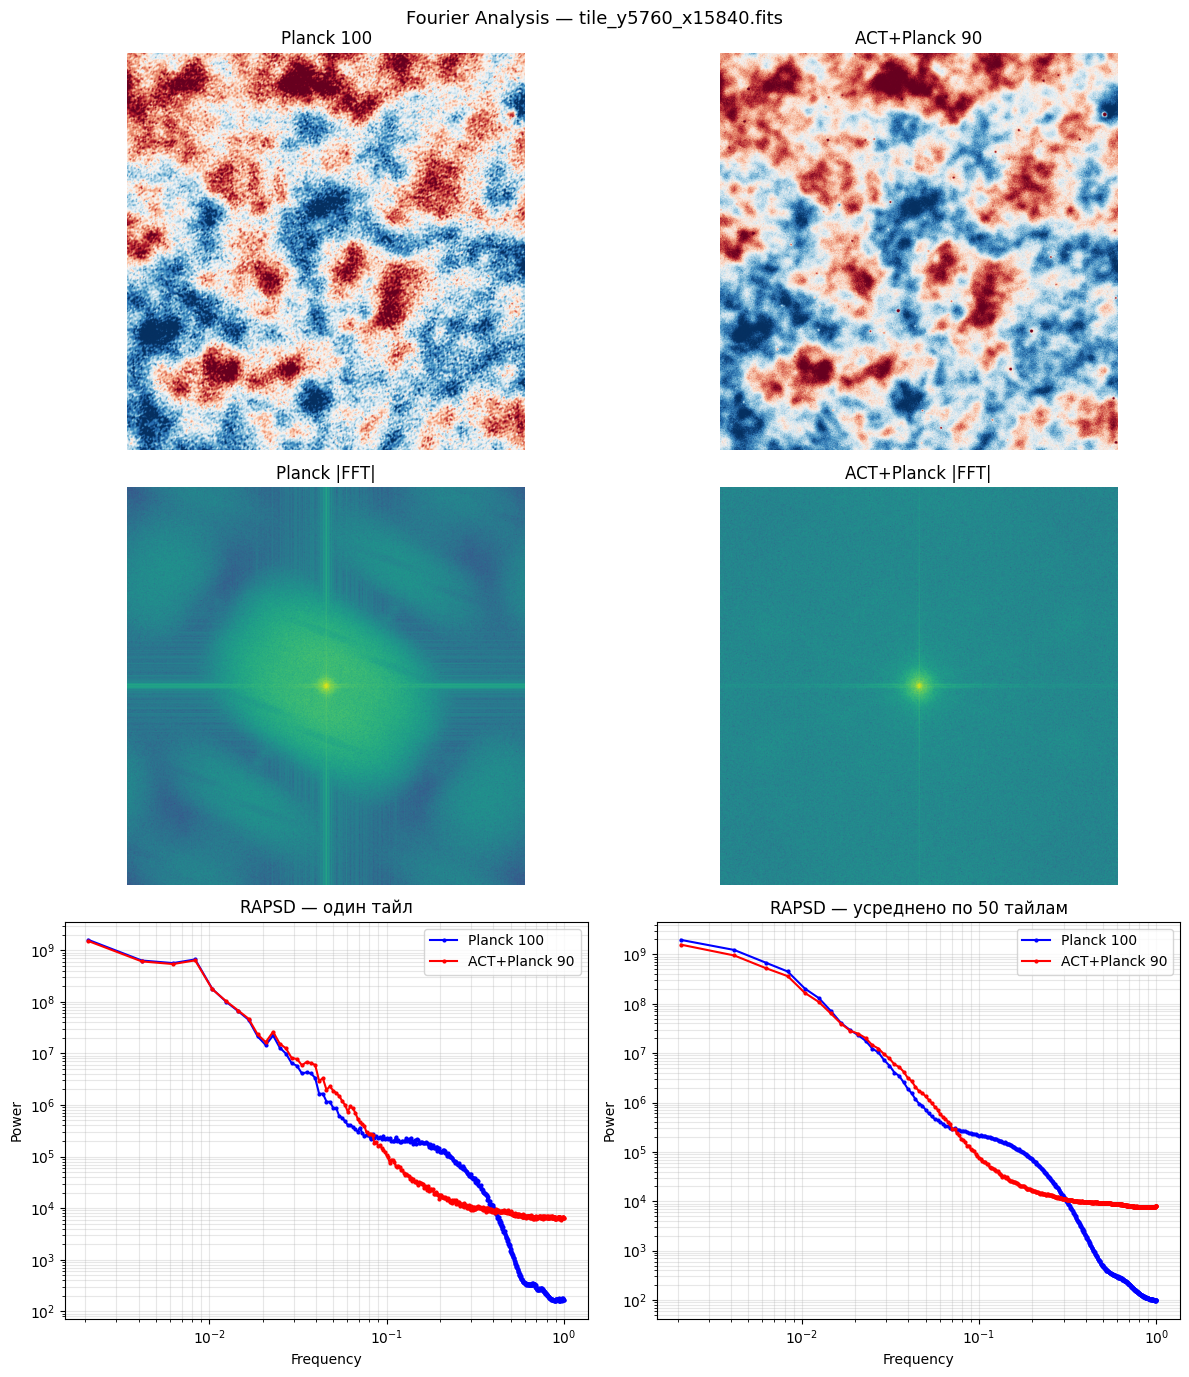

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os

planck_dir = os.path.join(BASE_DIR, "Planck", "f100")
act_dir    = os.path.join(BASE_DIR, "Planck+ACT", "f090")

tile_files = sorted(os.listdir(planck_dir))
fname = tile_files[len(tile_files) // 2]

with fits.open(os.path.join(planck_dir, fname)) as hdul:
    tile_p = hdul[0].data.astype(np.float32)
with fits.open(os.path.join(act_dir, fname)) as hdul:
    tile_a = hdul[0].data.astype(np.float32)

def compute_rapsd(tile):
    h, w = tile.shape
    spec = np.fft.fftshift(np.fft.fft2(tile))
    power = np.abs(spec)**2

    cy, cx = h // 2, w // 2
    y, x = np.indices(tile.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    r_max = min(cx, cy)
    mask = r < r_max

    rapsd = np.bincount(r[mask], weights=power[mask]) / np.bincount(r[mask])
    freqs = np.arange(r_max) / r_max
    return rapsd, freqs



def normalize(tile):
    valid = tile[tile != 0]
    vmin, vmax = valid.min(), valid.max()
    out = tile.copy()
    out[tile != 0] = 2 * (tile[tile != 0] - vmin) / (vmax - vmin) - 1
    return out

tile_p_norm = normalize(tile_p)
tile_a_norm = normalize(tile_a)

spec_p = np.fft.fftshift(np.fft.fft2(tile_p_norm))
spec_a = np.fft.fftshift(np.fft.fft2(tile_a_norm))

rapsd_p, freqs = compute_rapsd(tile_p_norm)
rapsd_a, _     = compute_rapsd(tile_a_norm)

fig, axes = plt.subplots(3, 2, figsize=(12, 14))

for col, (tile, label) in enumerate([(tile_p, "Planck 100"), (tile_a, "ACT+Planck 90")]):
    valid = tile[tile != 0]
    vmin, vmax = np.percentile(valid, [2, 98])
    axes[0, col].imshow(tile, cmap="RdBu_r", vmin=vmin, vmax=vmax, origin="lower")
    axes[0, col].set_title(label, fontsize=12)
    axes[0, col].axis("off")

for col, (spec, label) in enumerate([(spec_p, "Planck |FFT|"), (spec_a, "ACT+Planck |FFT|")]):
    axes[1, col].imshow(np.log(np.abs(spec) + 1e-10), cmap="viridis", origin="lower")
    axes[1, col].set_title(label, fontsize=12)
    axes[1, col].axis("off")

axes[2, 0].plot(freqs[1:], rapsd_p[1:], c="blue", marker="o", markersize=2, label="Planck 100")
axes[2, 0].plot(freqs[1:], rapsd_a[1:], c="red",  marker="o", markersize=2, label="ACT+Planck 90")
axes[2, 0].set_xscale("log")
axes[2, 0].set_yscale("log")
axes[2, 0].set_xlabel("Frequency")
axes[2, 0].set_ylabel("Power")
axes[2, 0].set_title("RAPSD — один тайл", fontsize=12)
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3, which="both")

n_avg = 50
accum_p = np.zeros(len(rapsd_p))
accum_a = np.zeros(len(rapsd_a))

for f in tile_files[:n_avg]:
    with fits.open(os.path.join(planck_dir, f)) as hdul:
        tp = normalize(hdul[0].data.astype(np.float32))
    with fits.open(os.path.join(act_dir, f)) as hdul:
        ta = normalize(hdul[0].data.astype(np.float32))
    r_p, _ = compute_rapsd(tp)
    r_a, _ = compute_rapsd(ta)
    accum_p += r_p
    accum_a += r_a

accum_p /= n_avg
accum_a /= n_avg

axes[2, 1].plot(freqs[1:], accum_p[1:], c="blue", marker="o", markersize=2, label="Planck 100")
axes[2, 1].plot(freqs[1:], accum_a[1:], c="red",  marker="o", markersize=2, label="ACT+Planck 90")
axes[2, 1].set_xscale("log")
axes[2, 1].set_yscale("log")
axes[2, 1].set_xlabel("Frequency")
axes[2, 1].set_ylabel("Power")
axes[2, 1].set_title(f"RAPSD — усреднено по {n_avg} тайлам", fontsize=12)
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3, which="both")

plt.suptitle(f"Fourier Analysis — {fname}", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
!wget -O /content/drive/MyDrive/Galaxy_Hackers/ACT_90_DR6.fits \
https://lambda.gsfc.nasa.gov/data/act/maps/published/act_dr4dr6_coadd_AA_daynight_f090_map.fits

--2026-04-16 10:19:23--  https://lambda.gsfc.nasa.gov/data/act/maps/published/act_dr4dr6_coadd_AA_daynight_f090_map.fits
Resolving lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)... 129.164.179.68, 2001:4d0:2310:150::68
Connecting to lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)|129.164.179.68|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5349890880 (5.0G)
Saving to: ‘/content/drive/MyDrive/Galaxy_Hackers/ACT_90_DR6.fits’

/content/drive/MyDr 100%[===================>]   4.98G  8.44MB/s    in 10m 6s  

2026-04-16 10:29:30 (8.42 MB/s) - ‘/content/drive/MyDrive/Galaxy_Hackers/ACT_90_DR6.fits’ saved [5349890880/5349890880]



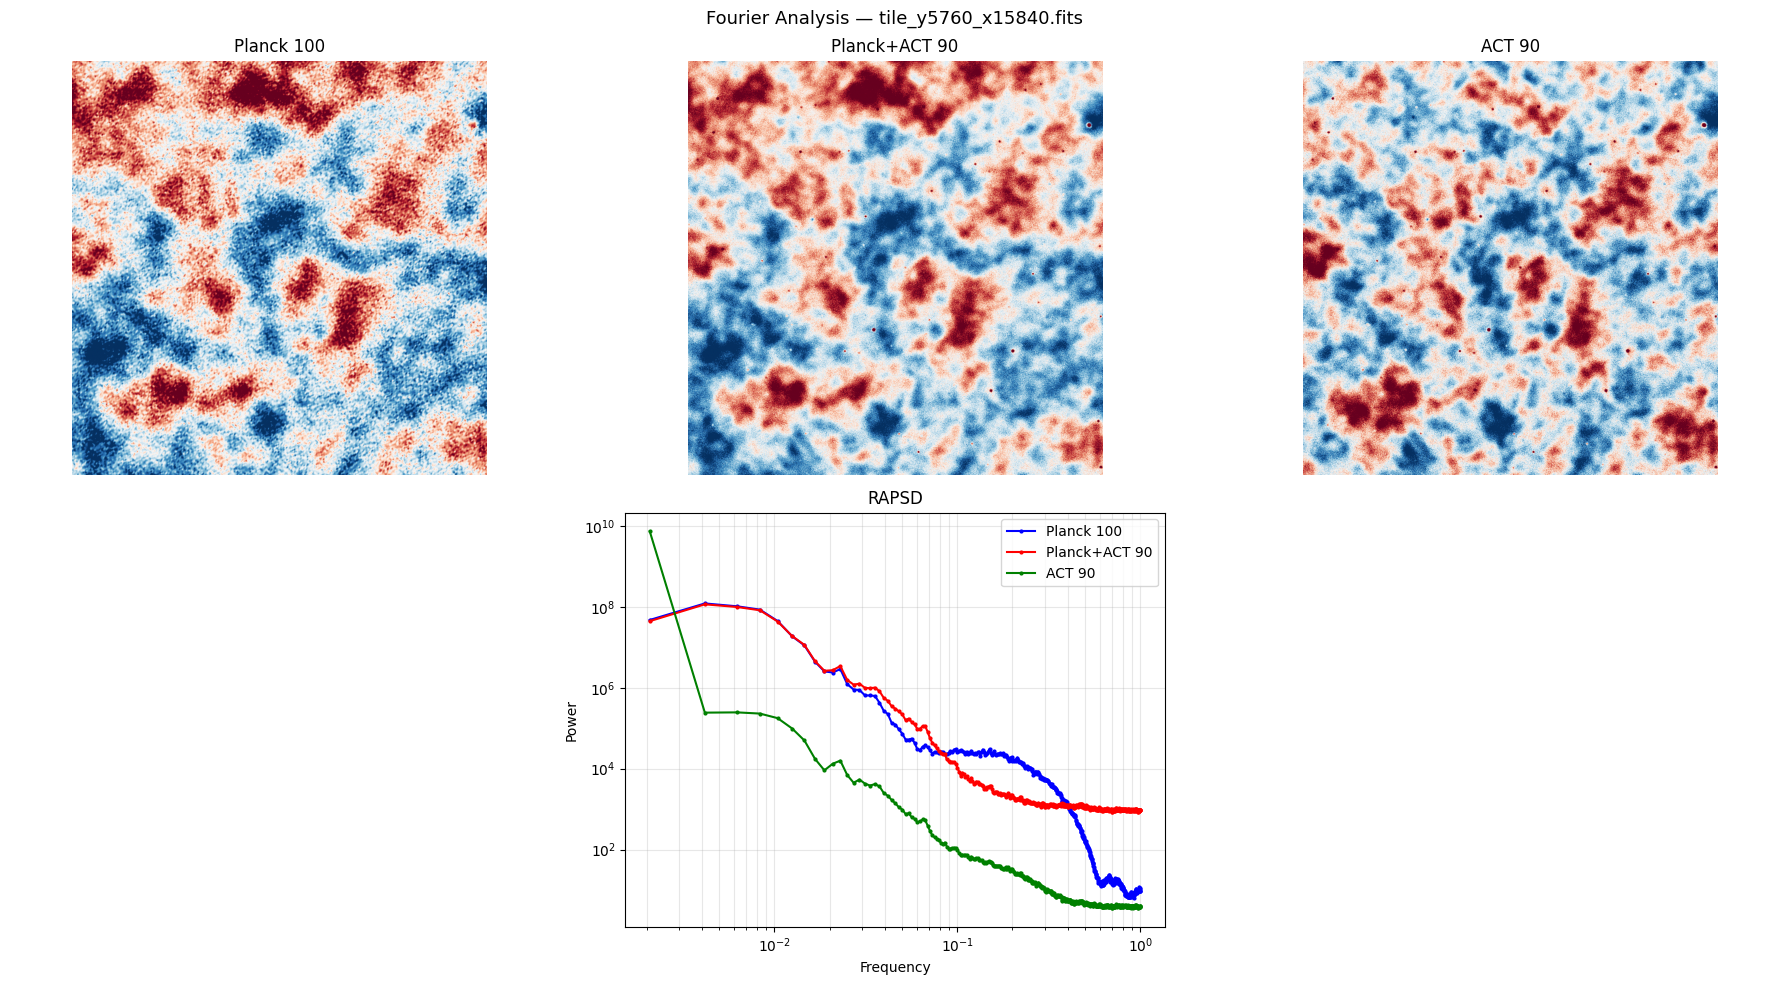

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from pixell import enmap
import os

planck_dir = os.path.join(BASE_DIR, "Planck", "f100")
act_dir    = os.path.join(BASE_DIR, "Planck+ACT", "f090")

tile_files = sorted(os.listdir(planck_dir))
fname = tile_files[len(tile_files) // 2]

with fits.open(os.path.join(planck_dir, fname)) as hdul:
    tile_p = hdul[0].data.astype(np.float32)

with fits.open(os.path.join(act_dir, fname)) as hdul:
    tile_pa = hdul[0].data.astype(np.float32)

y = int(fname.split("_y")[1].split("_")[0])
x = int(fname.split("_x")[1].replace(".fits", ""))

act_full = enmap.read_map("/content/drive/MyDrive/Galaxy_Hackers/ACT_90_DR6.fits")[0]
tile_a = np.array(act_full[y:y+TILE_SIZE, x:x+TILE_SIZE]).astype(np.float32)


def normalize(tile):
    valid = tile[tile != 0]
    if valid.size == 0:
        return tile
    vmin, vmax = valid.min(), valid.max()
    out = tile.copy()
    out[tile != 0] = 2 * (tile[tile != 0] - vmin) / (vmax - vmin) - 1
    return out


def azimuthal_average(power_2d):
    h, w = power_2d.shape
    cy, cx = h // 2, w // 2
    y_idx, x_idx = np.indices(power_2d.shape)
    r = np.sqrt((x_idx - cx)**2 + (y_idx - cy)**2).astype(int)
    r_max = min(cx, cy)
    mask = r < r_max
    rapsd = np.bincount(r[mask], weights=power_2d[mask]) / np.bincount(r[mask])
    freqs = np.arange(r_max) / r_max
    return rapsd, freqs


def compute_rapsd(tile):
    t = normalize(tile)
    window = np.outer(np.hanning(t.shape[0]), np.hanning(t.shape[1]))
    fft2 = np.fft.fftshift(np.fft.fft2(t * window))
    power = np.abs(fft2)**2
    return azimuthal_average(power)


rapsd_p,  freqs = compute_rapsd(tile_p)
rapsd_pa, _     = compute_rapsd(tile_pa)
rapsd_a,  _     = compute_rapsd(tile_a)


fig, axes = plt.subplots(2, 3, figsize=(18, 10))


for col, (tile, label) in enumerate(zip(
    [tile_p, tile_pa, tile_a],
    ["Planck 100", "Planck+ACT 90", "ACT 90"]
)):
    valid = tile[tile != 0]
    vmin, vmax = np.percentile(valid, [2, 98]) if valid.size > 0 else (0, 1)
    axes[0, col].imshow(tile, cmap="RdBu_r", vmin=vmin, vmax=vmax, origin="lower")
    axes[0, col].set_title(label, fontsize=12)
    axes[0, col].axis("off")


ax = axes[1, 1]
ax.loglog(freqs[1:], rapsd_p[1:],  color="blue",  marker="o", markersize=2, label="Planck 100")
ax.loglog(freqs[1:], rapsd_pa[1:], color="red",   marker="o", markersize=2, label="Planck+ACT 90")
ax.loglog(freqs[1:], rapsd_a[1:],  color="green", marker="o", markersize=2, label="ACT 90")
ax.set_xlabel("Frequency")
ax.set_ylabel("Power")
ax.set_title("RAPSD", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, which="both")
axes[1, 0].axis("off")
axes[1, 2].axis("off")

plt.suptitle(f"Fourier Analysis — {fname}", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:

from matplotlib import rc
rc('animation', html='jshtml')
import matplotlib.pyplot as plt
from matplotlib import animation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


tile_norm = normalize(tile_pa)


rapsd_orig, freqs = compute_rapsd(tile_pa)

noise = np.random.normal(0, 1, size=tile_norm.shape)
noise = noise.astype(np.float32)


num_steps = 8
noise_scale_min, noise_scale_max = 0.02, 50.0
noise_scales = np.logspace(np.log10(noise_scale_min), np.log10(noise_scale_max), num_steps)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.loglog(freqs[1:], rapsd_orig[1:], color="red", marker="o", markersize=2, label="Planck+ACT")
ax1.set_xlabel("Frequency")
ax1.set_ylabel("Power")
ax1.set_title("RAPSD")
ax1.grid(True, alpha=0.3, which="both")
ax2.axis("off")

artists = []

for scale in noise_scales:
    current_noise = scale * noise
    noisy_tile = tile_norm + current_noise


    rapsd_noise, _ = compute_rapsd(current_noise)
    rapsd_noisy, _ = compute_rapsd(noisy_tile)

    container  = ax1.loglog(freqs[1:], rapsd_noise[1:],  color="blue",  marker="o", markersize=2, label=f"noise ×{scale:.2f}")
    container += ax1.loglog(freqs[1:], rapsd_noisy[1:],  color="green", marker="o", markersize=2, label="noisy")


    noisy_vis = np.clip((noisy_tile + 1) / 2, 0, 1)
    im = ax2.imshow(noisy_vis, cmap="RdBu_r", vmin=0, vmax=1, origin="lower",
                    animated=True)
    title = ax2.text(0.5, 1.01, f"noise scale = {scale:.2f}",
                     transform=ax2.transAxes, ha="center", fontsize=10)
    container += [im, title]

    artists.append(container)

plt.tight_layout()
plt.close()

anim = animation.ArtistAnimation(fig=fig, artists=artists,
                                  interval=800, repeat=True)
anim

In [ ]:
anim.save("noisy_animation_planck+act.gif", dpi=150)
from google.colab import files
files.download("noisy_animation_planck+act.gif")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


D56:
  Rows: 6839:7799, Cols: 16799:19799
  Region shape: (960, 3000)
  Valid patches: 33

AA:
  Rows: 959:3959, Cols: 11999:19199
  Region shape: (3000, 7200)
  Valid patches: 319

BN:
  Rows: 8159:9959, Cols: 21600:27600
  Region shape: (1800, 6000)
  Valid patches: 144


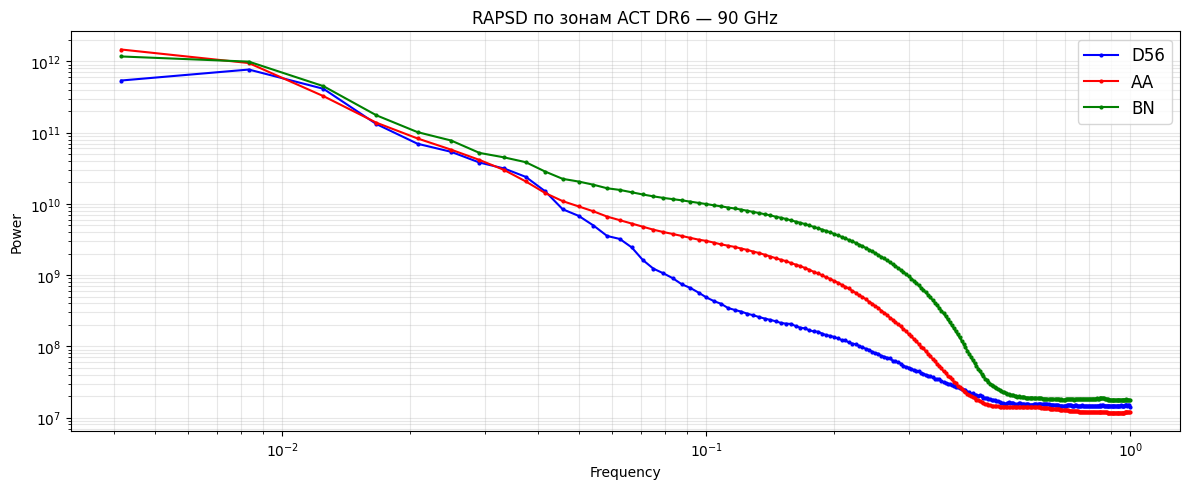

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

with fits.open("/content/drive/MyDrive/Galaxy_Hackers/ACT_90_DR6.fits") as hdul:
    act_full = hdul[0].data[0].astype(np.float32)
    hdr = hdul[0].header


cdelt = abs(hdr["CDELT2"])
crpix2 = hdr["CRPIX2"]
crval2 = hdr["CRVAL2"]
crpix1 = hdr["CRPIX1"]

def dec_to_row(dec_deg):
    """Dec в градусах → строка пикселя."""
    return int(crpix2 - 1 + dec_deg / cdelt)

def ra_to_col(ra_deg):
    """RA в градусах → столбец пикселя. Обрабатывает wrap-around."""

    if ra_deg > 180:
        ra_deg = ra_deg - 360
    return int(crpix1 - 1 - ra_deg / cdelt)

ZONES = {
    "D56": {"dec": (-6,  +2),  "ra": (15,   40)},
    "AA":  {"dec": (-55, -30), "ra": (20,   80)},
    "BN":  {"dec": (+5,  +20), "ra": (310, 360)},
}


def extract_zone_patches(data, dec_min, dec_max, ra_min, ra_max,
                          patch_size=480, stride=240, max_zero_frac=0.3):
    row_min = dec_to_row(dec_min)
    row_max = dec_to_row(dec_max)
    col_min = ra_to_col(ra_max)
    col_max = ra_to_col(ra_min)

    h, w = data.shape
    row_min = max(0, row_min)
    row_max = min(h, row_max)
    col_min = max(0, col_min)
    col_max = min(w, col_max)

    print(f"  Rows: {row_min}:{row_max}, Cols: {col_min}:{col_max}")
    region = data[row_min:row_max, col_min:col_max]
    print(f"  Region shape: {region.shape}")

    patches = []
    for y in range(0, region.shape[0] - patch_size + 1, stride):
        for x in range(0, region.shape[1] - patch_size + 1, stride):
            patch = region[y:y+patch_size, x:x+patch_size]
            if (patch == 0).mean() <= max_zero_frac:
                patches.append(patch)

    print(f"  Valid patches: {len(patches)}")
    return patches


def compute_rapsd(patch):
    h, w = patch.shape
    window = np.outer(np.hanning(h), np.hanning(w))
    fft2   = np.fft.fftshift(np.fft.fft2(patch * window))
    power  = np.abs(fft2)**2
    cy, cx = h // 2, w // 2
    y, x   = np.indices(power.shape)
    r      = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    r_max  = min(cx, cy)
    mask   = r < r_max
    rapsd  = np.bincount(r[mask], weights=power[mask]) / np.bincount(r[mask])
    freqs  = np.arange(r_max) / r_max
    return rapsd, freqs


def mean_rapsd(patches):
    accum = None
    for p in patches:
        r, freqs = compute_rapsd(p)
        accum = r if accum is None else accum + r
    return accum / len(patches), freqs



colors = {"D56": "blue", "AA": "red", "BN": "green"}
results = {}

for zone, coords in ZONES.items():
    print(f"\n{zone}:")
    patches = extract_zone_patches(
        act_full,
        dec_min=coords["dec"][0], dec_max=coords["dec"][1],
        ra_min=coords["ra"][0],   ra_max=coords["ra"][1],
    )
    if len(patches) > 0:
        rapsd, freqs = mean_rapsd(patches)
        results[zone] = (rapsd, freqs)

fig, ax = plt.subplots(figsize=(12, 5))

for zone, (rapsd, freqs) in results.items():
    ax.loglog(freqs[1:], rapsd[1:], color=colors[zone],
              marker="o", markersize=2, label=zone)

ax.set_xlabel("Frequency")
ax.set_ylabel("Power")
ax.set_title("RAPSD по зонам ACT DR6 — 90 GHz")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

In [ ]:
with fits.open("planck100_fully_masked.fits") as hdul:
    planck_full = hdul[0].data.astype(np.float32)

print(f"Planck shape: {planck_full.shape}")
print(f"ACT shape:    {act_full.shape}")

Planck shape: (10320, 43200)
ACT shape:    (10320, 43200)



Planck D56:
  Rows: 6839:7799, Cols: 16799:19799
  Region shape: (960, 3000)
  Valid patches: 33

Planck AA:
  Rows: 959:3959, Cols: 11999:19199
  Region shape: (3000, 7200)
  Valid patches: 319

Planck BN:
  Rows: 8159:9959, Cols: 21600:27600
  Region shape: (1800, 6000)
  Valid patches: 118


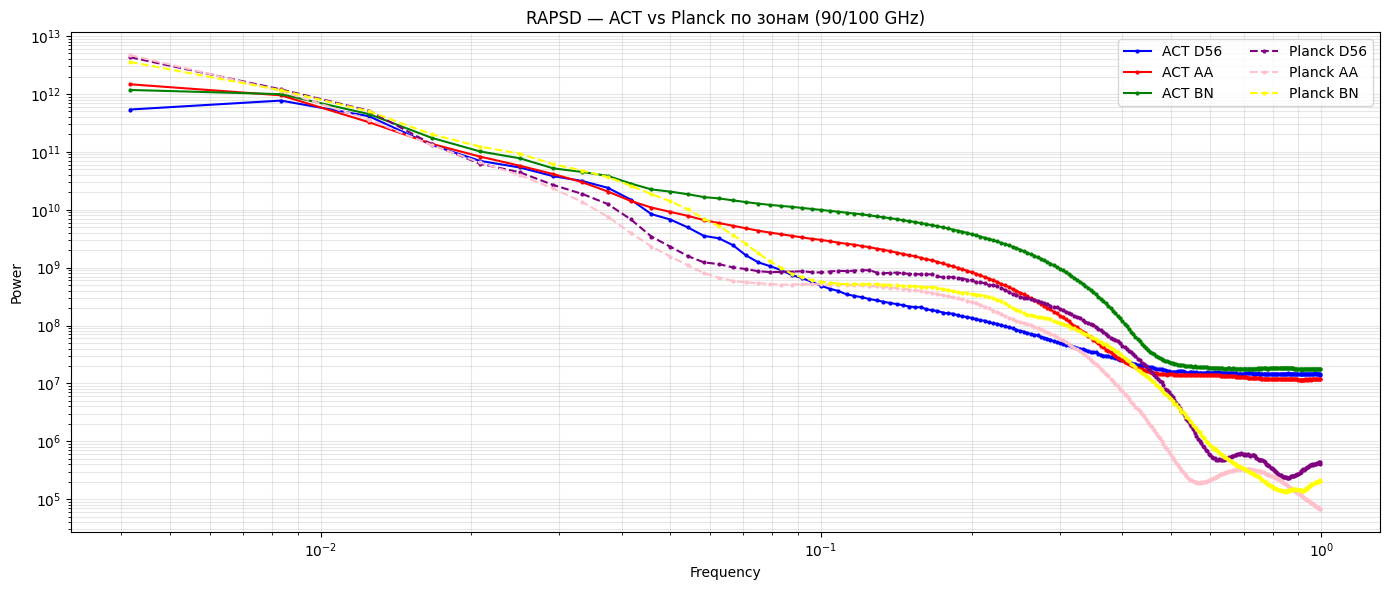

In [ ]:
colors_act    = {"D56": "blue",  "AA": "red",    "BN": "green"}
colors_planck = {"D56": "purple", "AA": "pink", "BN": "yellow"}
results_planck = {}

for zone, coords in ZONES.items():
    print(f"\nPlanck {zone}:")
    patches = extract_zone_patches(
        planck_full,
        dec_min=coords["dec"][0], dec_max=coords["dec"][1],
        ra_min=coords["ra"][0],   ra_max=coords["ra"][1],
    )
    if len(patches) > 0:
        rapsd, freqs = mean_rapsd(patches)
        results_planck[zone] = (rapsd, freqs)

fig, ax = plt.subplots(figsize=(14, 6))

for zone, (rapsd, freqs) in results.items():
    ax.loglog(freqs[1:], rapsd[1:], color=colors_act[zone],
              marker="o", markersize=2, label=f"ACT {zone}", linewidth=1.5)

for zone, (rapsd, freqs) in results_planck.items():
    ax.loglog(freqs[1:], rapsd[1:], color=colors_planck[zone],
              marker="o", markersize=2, label=f"Planck {zone}",
              linewidth=1.5, linestyle="--")

ax.set_xlabel("Frequency")
ax.set_ylabel("Power")
ax.set_title("RAPSD — ACT vs Planck по зонам (90/100 GHz)")
ax.legend(fontsize=10, ncol=2)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()